# 第九课：优化器与学习率调度

## 为什么优化器很重要？

深度学习训练 = 在高维参数空间中寻找最优解。优化器决定了"怎么走"，学习率决定了"走多远"。

好的优化策略可以：
- 加速收敛
- 避免陷入局部最优
- 提高最终性能

## 本课内容

1. 梯度下降的变体
2. 常用优化器详解
3. 学习率调度
4. 实战对比

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

## 1. 梯度下降的三种形式

In [2]:
print("=== 梯度下降三种形式 ===")
print()
print("1. 批量梯度下降 (BGD)")
print("   用全部数据计算梯度")
print("   优点: 梯度准确  缺点: 计算量大，无法处理大数据集")
print()
print("2. 随机梯度下降 (SGD)")
print("   每次用1个样本计算梯度")
print("   优点: 速度快  缺点: 梯度噪声大，训练不稳定")
print()
print("3. Mini-batch 梯度下降")
print("   每次用一小批样本计算梯度")
print("   优点: 兼顾速度和稳定性  缺点: 需要调 batch_size")
print()
print("实际中几乎都用 Mini-batch，PyTorch 的 DataLoader 就是为此设计")

=== 梯度下降三种形式 ===

1. 批量梯度下降 (BGD)
   用全部数据计算梯度
   优点: 梯度准确  缺点: 计算量大，无法处理大数据集

2. 随机梯度下降 (SGD)
   每次用1个样本计算梯度
   优点: 速度快  缺点: 梯度噪声大，训练不稳定

3. Mini-batch 梯度下降
   每次用一小批样本计算梯度
   优点: 兼顾速度和稳定性  缺点: 需要调 batch_size

实际中几乎都用 Mini-batch，PyTorch 的 DataLoader 就是为此设计


## 2. 常用优化器详解

In [3]:
# 准备实验数据
torch.manual_seed(42)
n_samples = 1000
X = torch.randn(n_samples, 10)
W_true = torch.randn(10, 3)
logits = X @ W_true
y = logits.argmax(dim=1)

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

def create_model():
    return nn.Sequential(
        nn.Linear(10, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 3)
    )

criterion = nn.CrossEntropyLoss()

print("实验数据准备完成")
print(f"样本数: {n_samples}, 特征维度: 10, 类别数: 3")

实验数据准备完成
样本数: 1000, 特征维度: 10, 类别数: 3


In [4]:
# SGD
print("=== SGD (随机梯度下降) ===")
print()
print("公式: w = w - lr * grad")
print()
print("最基础的优化器，PyTorch 中的 SGD 其实是 Mini-batch SGD")
print("优点: 简单，泛化性能好")
print("缺点: 收敛慢，对学习率敏感，容易陷入鞍点")
print()
print("optimizer = optim.SGD(model.parameters(), lr=0.01)")

=== SGD (随机梯度下降) ===

公式: w = w - lr * grad

最基础的优化器，PyTorch 中的 SGD 其实是 Mini-batch SGD
优点: 简单，泛化性能好
缺点: 收敛慢，对学习率敏感，容易陷入鞍点

optimizer = optim.SGD(model.parameters(), lr=0.01)


In [5]:
# SGD + Momentum
print("=== SGD + Momentum ===")
print()
print("动量: 累积历史梯度方向，加速收敛，减少震荡")
print()
print("v_t = momentum * v_{t-1} + grad")
print("w = w - lr * v_t")
print()
print("momentum=0.9 是常用值")
print("类比: 小球滚下山坡，有惯性，不会在小坑里停下")
print()
print("optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)")

=== SGD + Momentum ===

动量: 累积历史梯度方向，加速收敛，减少震荡

v_t = momentum * v_{t-1} + grad
w = w - lr * v_t

momentum=0.9 是常用值
类比: 小球滚下山坡，有惯性，不会在小坑里停下

optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)


In [6]:
# Adam
print("=== Adam ===")
print()
print("结合 Momentum + RMSprop 的自适应学习率优化器")
print()
print("m_t = beta1 * m_{t-1} + (1-beta1) * grad     # 一阶矩（动量）")
print("v_t = beta2 * v_{t-1} + (1-beta2) * grad^2   # 二阶矩（自适应学习率）")
print("m_hat = m_t / (1-beta1^t)                      # 偏差修正")
print("v_hat = v_t / (1-beta2^t)                      # 偏差修正")
print("w = w - lr * m_hat / (sqrt(v_hat) + eps)")
print()
print("默认参数: lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8")
print("优点: 自适应学习率，对不同参数自动调整步长")
print("缺点: 泛化性能可能不如 SGD+Momentum")
print()
print("optimizer = optim.Adam(model.parameters(), lr=0.001)")

=== Adam ===

结合 Momentum + RMSprop 的自适应学习率优化器

m_t = beta1 * m_{t-1} + (1-beta1) * grad     # 一阶矩（动量）
v_t = beta2 * v_{t-1} + (1-beta2) * grad^2   # 二阶矩（自适应学习率）
m_hat = m_t / (1-beta1^t)                      # 偏差修正
v_hat = v_t / (1-beta2^t)                      # 偏差修正
w = w - lr * m_hat / (sqrt(v_hat) + eps)

默认参数: lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8
优点: 自适应学习率，对不同参数自动调整步长
缺点: 泛化性能可能不如 SGD+Momentum

optimizer = optim.Adam(model.parameters(), lr=0.001)


In [7]:
# AdamW
print("=== AdamW ===")
print()
print("Adam 的改进版，解耦了权重衰减和梯度更新")
print()
print("Adam + L2正则: grad = grad + weight_decay * w  (耦合)")
print("AdamW:         w = w - lr * weight_decay * w   (解耦)")
print()
print("Transformer 训练的标准选择")
print()
print("optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)")

=== AdamW ===

Adam 的改进版，解耦了权重衰减和梯度更新

Adam + L2正则: grad = grad + weight_decay * w  (耦合)
AdamW:         w = w - lr * weight_decay * w   (解耦)

Transformer 训练的标准选择

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)


In [8]:
# 其他优化器简介
print("=== 其他优化器 ===")
print()
print("RMSprop:  自适应学习率，适合 RNN")
print("Adagrad:  对低频特征给更大学习率，但学习率只减不增")
print("Adamax:   Adam 的变体，基于无穷范数")
print("NAdam:    Adam + Nesterov 动量")
print()
print("选择建议:")
print("  默认首选: Adam (lr=0.001)")
print("  追求极致性能: SGD+Momentum (需要仔细调学习率)")
print("  Transformer: AdamW")
print("  RNN: Adam 或 RMSprop")

=== 其他优化器 ===

RMSprop:  自适应学习率，适合 RNN
Adagrad:  对低频特征给更大学习率，但学习率只减不增
Adamax:   Adam 的变体，基于无穷范数
NAdam:    Adam + Nesterov 动量

选择建议:
  默认首选: Adam (lr=0.001)
  追求极致性能: SGD+Momentum (需要仔细调学习率)
  Transformer: AdamW
  RNN: Adam 或 RMSprop


## 3. 优化器实战对比

In [9]:
def train_with_optimizer(optimizer_class, lr, epochs=100, **kwargs):
    torch.manual_seed(42)
    model = create_model()
    optimizer = optimizer_class(model.parameters(), lr=lr, **kwargs)
    
    losses = []
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(loader))
    
    return losses

optimizers = {
    'SGD (lr=0.1)': (optim.SGD, 0.1),
    'SGD+Momentum (lr=0.1)': (optim.SGD, 0.1, {'momentum': 0.9}),
    'Adam (lr=0.01)': (optim.Adam, 0.01),
    'AdamW (lr=0.01)': (optim.AdamW, 0.01, {'weight_decay': 0.01}),
}

results = {}
for name, config in optimizers.items():
    opt_class, lr = config[0], config[1]
    kwargs = config[2] if len(config) > 2 else {}
    losses = train_with_optimizer(opt_class, lr, **kwargs)
    results[name] = losses
    print(f"{name:30s} -> 最终 loss: {losses[-1]:.4f}")

SGD (lr=0.1)                   -> 最终 loss: 0.0095
SGD+Momentum (lr=0.1)          -> 最终 loss: 0.0001
Adam (lr=0.01)                 -> 最终 loss: 0.0001
AdamW (lr=0.01)                -> 最终 loss: 0.0003


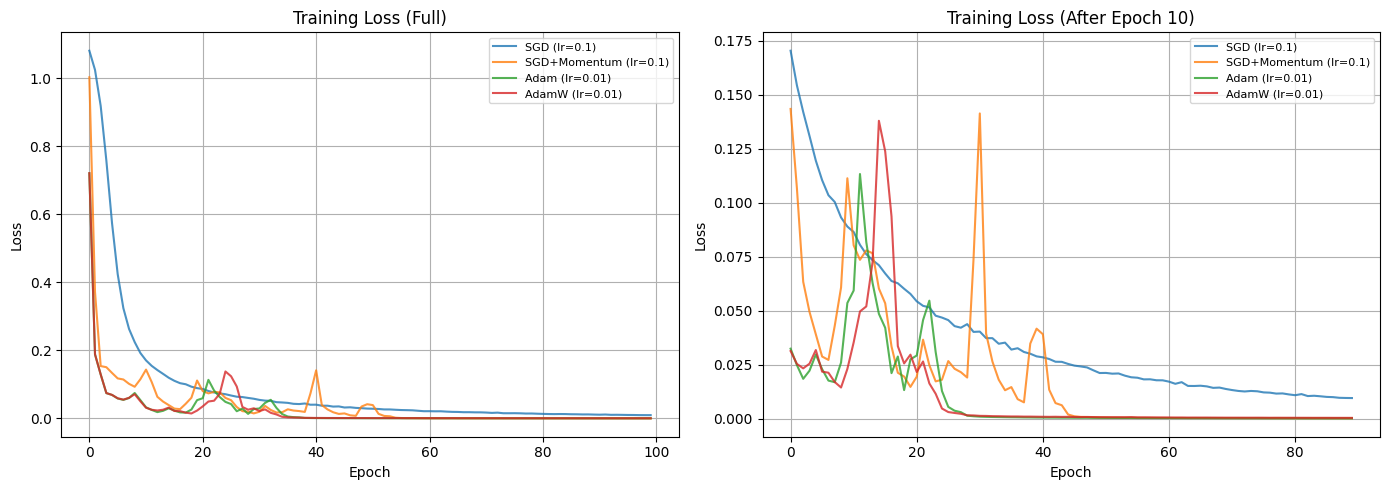

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, losses in results.items():
    axes[0].plot(losses, label=name, alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss (Full)')
axes[0].legend(fontsize=8)
axes[0].grid(True)

for name, losses in results.items():
    axes[1].plot(losses[10:], label=name, alpha=0.8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training Loss (After Epoch 10)')
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 4. 学习率的影响

In [11]:
lrs = [0.0001, 0.001, 0.01, 0.1, 1.0]
lr_results = {}

for lr in lrs:
    losses = train_with_optimizer(optim.SGD, lr, epochs=100, momentum=0.9)
    lr_results[f'lr={lr}'] = losses
    print(f"lr={lr:8.4f} -> 最终 loss: {losses[-1]:.4f}")

lr=  0.0001 -> 最终 loss: 1.0532
lr=  0.0010 -> 最终 loss: 0.1740
lr=  0.0100 -> 最终 loss: 0.0090
lr=  0.1000 -> 最终 loss: 0.0001
lr=  1.0000 -> 最终 loss: 1.1159


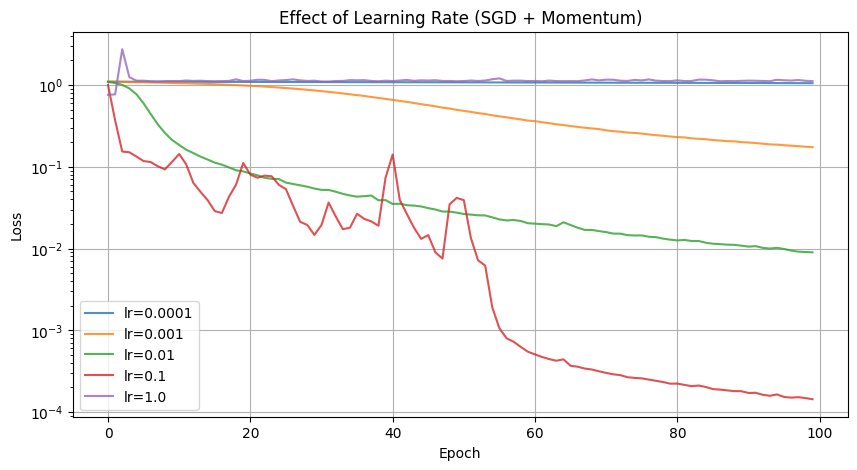

学习率太小: 收敛极慢
学习率太大: 震荡甚至发散
学习率合适: 快速稳定收敛


In [12]:
plt.figure(figsize=(10, 5))
for name, losses in lr_results.items():
    plt.plot(losses, label=name, alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Effect of Learning Rate (SGD + Momentum)')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

print("学习率太小: 收敛极慢")
print("学习率太大: 震荡甚至发散")
print("学习率合适: 快速稳定收敛")

## 5. 学习率调度（Learning Rate Scheduling）

训练初期用大学习率快速收敛，后期用小学习率精细调整。

In [13]:
# StepLR: 每隔 step_size 个 epoch，学习率乘以 gamma
model = create_model()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

lrs_step = []
for epoch in range(100):
    lrs_step.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

print("StepLR: 每30个epoch，lr *= 0.1")
print(f"  Epoch 0: lr={lrs_step[0]}")
print(f"  Epoch 30: lr={lrs_step[30]}")
print(f"  Epoch 60: lr={lrs_step[60]}")
print(f"  Epoch 90: lr={lrs_step[90]}")

StepLR: 每30个epoch，lr *= 0.1
  Epoch 0: lr=0.1
  Epoch 30: lr=0.010000000000000002
  Epoch 60: lr=0.0010000000000000002
  Epoch 90: lr=0.00010000000000000003


C:\Users\Administrator\AppData\Local\Temp\ipykernel_27716\489605711.py:9: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


In [14]:
# MultiStepLR: 在指定的 epoch 降低学习率
model = create_model()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[50, 80], gamma=0.1)

lrs_multi = []
for epoch in range(100):
    lrs_multi.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

print("MultiStepLR: 在 epoch 50 和 80 降低学习率")

MultiStepLR: 在 epoch 50 和 80 降低学习率


C:\Users\Administrator\AppData\Local\Temp\ipykernel_27716\1788217728.py:9: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


In [ ]:
# ExponentialLR: 每个 epoch 学习率乘以 gamma
model = create_model()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

lrs_exp = []
for epoch in range(100):
    lrs_exp.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

print(f"ExponentialLR: lr *= 0.95 每个 epoch")
print(f"  Epoch 0: lr={lrs_exp[0]:.6f}")
print(f"  Epoch 50: lr={lrs_exp[50]:.6f}")
print(f"  Epoch 99: lr={lrs_exp[99]:.6f}")

In [15]:
# CosineAnnealingLR: 余弦退火
model = create_model()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

lrs_cosine = []
for epoch in range(100):
    lrs_cosine.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

print("CosineAnnealingLR: 学习率按余弦曲线从 lr 衰减到 0")
print("  平滑下降，训练后期更精细")

CosineAnnealingLR: 学习率按余弦曲线从 lr 衰减到 0
  平滑下降，训练后期更精细


C:\Users\Administrator\AppData\Local\Temp\ipykernel_27716\478341766.py:9: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


In [ ]:
# ReduceLROnPlateau: 当指标不再改善时降低学习率
model = create_model()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, verbose=False
)

print("ReduceLROnPlateau: 验证损失连续 patience 个 epoch 不下降时，lr *= factor")
print("  mode='min': 监控指标越小越好")
print("  factor=0.5: 降低50%")
print("  patience=10: 容忍10个epoch不改善")
print()
print("使用方式不同于其他 scheduler:")
print("  scheduler.step(val_loss)  # 传入验证损失")
print("  其他 scheduler: scheduler.step()  # 不需要参数")

In [ ]:
# CosineAnnealingWarmRestarts: 带热重启的余弦退火
model = create_model()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=20, T_mult=2
)

lrs_warm = []
for epoch in range(100):
    lrs_warm.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

print("CosineAnnealingWarmRestarts:")
print("  T_0=20: 第一个周期20个epoch")
print("  T_mult=2: 每次周期长度翻倍 (20, 40, 80...)")
print("  周期性重启学习率，有助于跳出局部最优")

NameError: name 'lrs_exp' is not defined

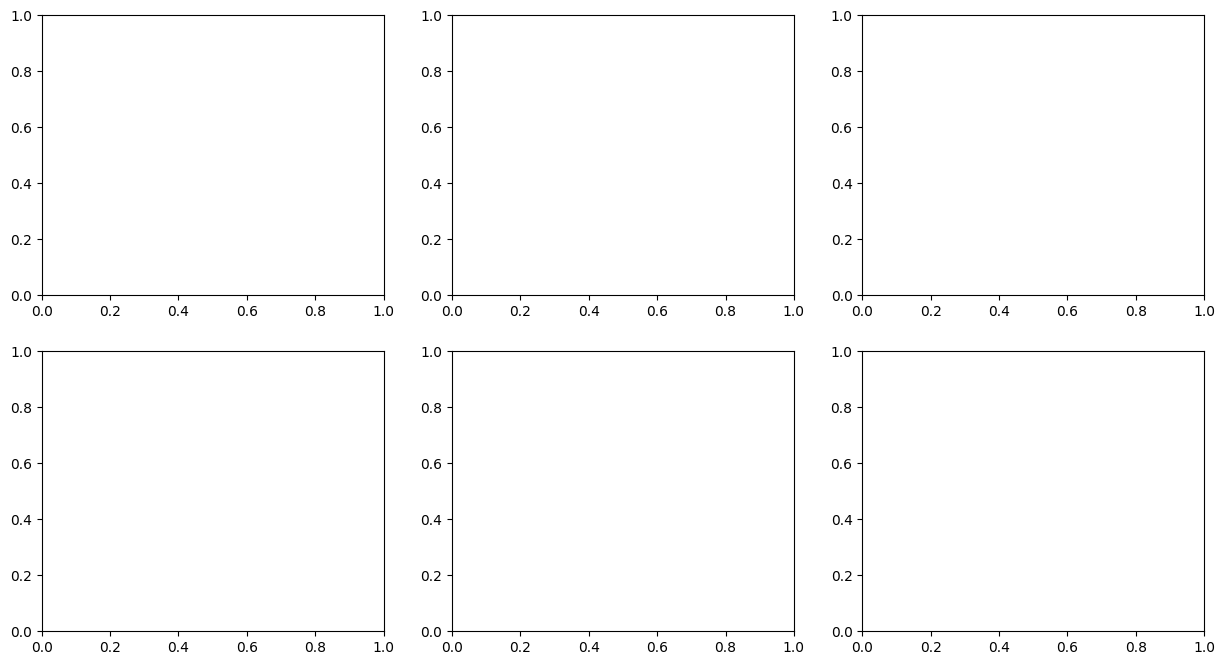

In [16]:
# 可视化所有调度策略
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

schedules = [
    ('StepLR', lrs_step),
    ('MultiStepLR', lrs_multi),
    ('ExponentialLR', lrs_exp),
    ('CosineAnnealingLR', lrs_cosine),
    ('WarmRestarts', lrs_warm),
]

for ax, (name, lrs) in zip(axes.flatten(), schedules):
    ax.plot(lrs, linewidth=2)
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.grid(True)

axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

## 6. 学习率调度实战对比

In [17]:
def train_with_scheduler(scheduler_class, epochs=100, **scheduler_kwargs):
    torch.manual_seed(42)
    model = create_model()
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    scheduler = scheduler_class(optimizer, **scheduler_kwargs)
    
    losses = []
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(loader))
        scheduler.step()
    
    return losses

no_schedule = train_with_scheduler(optim.lr_scheduler.StepLR, step_size=1000)
step_lr = train_with_scheduler(optim.lr_scheduler.StepLR, step_size=30, gamma=0.1)
cosine_lr = train_with_scheduler(optim.lr_scheduler.CosineAnnealingLR, T_max=100)
exp_lr = train_with_scheduler(optim.lr_scheduler.ExponentialLR, gamma=0.96)

schedule_results = {
    'No Schedule': no_schedule,
    'StepLR (30, 0.1)': step_lr,
    'CosineAnnealing': cosine_lr,
    'Exponential (0.96)': exp_lr,
}

for name, losses in schedule_results.items():
    print(f"{name:25s} -> 最终 loss: {losses[-1]:.4f}")

No Schedule               -> 最终 loss: 0.0001
StepLR (30, 0.1)          -> 最终 loss: 0.0017
CosineAnnealing           -> 最终 loss: 0.0005
Exponential (0.96)        -> 最终 loss: 0.0019


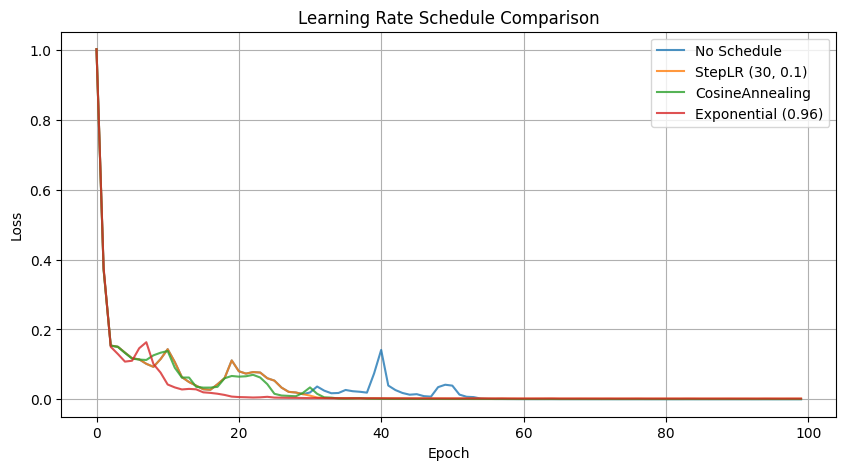

学习率调度通常能带来更好的最终性能


In [18]:
plt.figure(figsize=(10, 5))
for name, losses in schedule_results.items():
    plt.plot(losses, label=name, alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Rate Schedule Comparison')
plt.legend()
plt.grid(True)
plt.show()

print("学习率调度通常能带来更好的最终性能")

## 7. 学习率预热（Warmup）

In [ ]:
# 手动实现线性预热
def get_linear_warmup_scheduler(optimizer, warmup_epochs, total_epochs, base_lr):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / warmup_epochs  # 线性从0增到1
        else:
            progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
            return 0.5 * (1 + np.cos(np.pi * progress))  # 余弦衰减
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

torch.manual_seed(42)
model = create_model()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
scheduler = get_linear_warmup_scheduler(optimizer, warmup_epochs=10, total_epochs=100, base_lr=0.1)

lrs_warmup = []
for epoch in range(100):
    lrs_warmup.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

plt.figure(figsize=(8, 4))
plt.plot(lrs_warmup, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Linear Warmup + Cosine Decay')
plt.grid(True)
plt.annotate('Warmup', xy=(5, lrs_warmup[5]), fontsize=10, color='red')
plt.annotate('Cosine Decay', xy=(60, lrs_warmup[60]), fontsize=10, color='blue')
plt.show()

print("Warmup: 训练初期用很小的学习率，逐渐增大到目标学习率")
print("原因: 初始参数随机，大学习率可能导致训练不稳定")
print("Transformer 训练的标配: Linear Warmup + Cosine Decay")

## 8. 完整训练模板（含调度器）

In [ ]:
print("=== 完整训练模板 ===")
print()
print("model = MyModel()")
print("optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)")
print("scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)")
print()
print("for epoch in range(epochs):")
print("    model.train()")
print("    for X_batch, y_batch in train_loader:")
print("        loss = criterion(model(X_batch), y_batch)")
print("        optimizer.zero_grad()")
print("        loss.backward()")
print("        optimizer.step()")
print("    ")
print("    model.eval()")
print("    val_loss = evaluate(model, val_loader)")
print("    ")
print("    scheduler.step()  # 注意: 在 epoch 结束后调用")
print("    ")
print("    # 如果用 ReduceLROnPlateau:")
print("    # scheduler.step(val_loss)")
print()
print("重要: scheduler.step() 的位置")
print("  一般调度器: 在每个 epoch 结束后调用")
print("  ReduceLROnPlateau: 传入验证指标")

## 9. 梯度累积（模拟大 batch_size）

In [ ]:
print("=== 梯度累积 ===")
print()
print("当 GPU 显存不够，无法使用大 batch_size 时，")
print("可以用梯度累积来模拟大 batch_size 的效果")
print()
print("accumulation_steps = 4  # 累积4个小batch")
print()
print("optimizer.zero_grad()")
print("for i, (X_batch, y_batch) in enumerate(train_loader):")
print("    loss = criterion(model(X_batch), y_batch)")
print("    loss = loss / accumulation_steps  # 缩放损失")
print("    loss.backward()  # 梯度累积")
print("    ")
print("    if (i + 1) % accumulation_steps == 0:")
print("        optimizer.step()  # 累积够了才更新")
print("        optimizer.zero_grad()")
print()
print("效果: batch_size=32, accumulation_steps=4 -> 等效 batch_size=128")

---
## 总结

### 优化器选择指南

| 场景 | 推荐优化器 | 学习率 |
|------|-----------|--------|
| 快速实验 | Adam | 0.001 |
| 追求极致 | SGD+Momentum | 0.1 (需调) |
| Transformer | AdamW | 0.001 |
| RNN | Adam/RMSprop | 0.001 |

### 学习率调度选择

| 调度器 | 特点 | 适用场景 |
|--------|------|----------|
| StepLR | 阶梯式下降 | 简单任务 |
| CosineAnnealingLR | 平滑下降 | 通用，效果好 |
| ExponentialLR | 指数衰减 | 需要快速衰减 |
| ReduceLROnPlateau | 自适应 | 不确定何时衰减 |
| Warmup+Cosine | 先升后降 | Transformer标配 |

### 关键原则
- **学习率是最重要的超参数**，优先调它
- Adam 是最稳妥的默认选择
- 配合学习率调度通常能提升性能
- 大模型训练需要 Warmup
- 显存不够时用梯度累积模拟大 batch